In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

sales_data = pd.read_csv('https://www.statlearning.com/s/Advertising.csv', index_col=0)

# Exercise 1
### Visualize data as a heatmap and in another way of your choice.

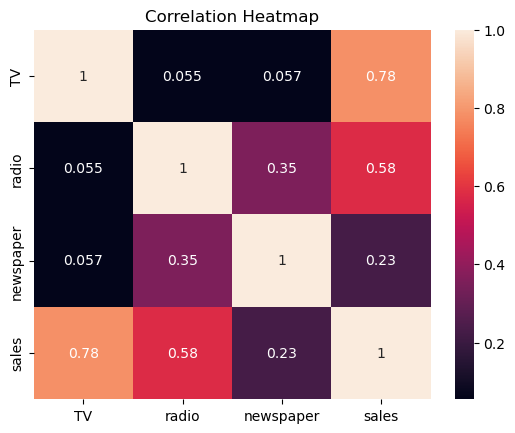

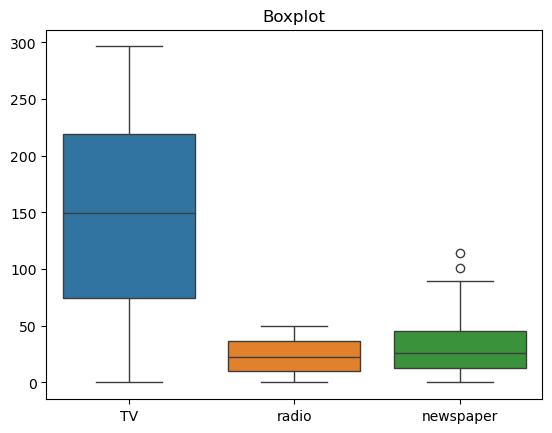

In [171]:
# Your Code here





sns.heatmap(data= sales_data.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()
plt.show()


sns.boxplot(data=sales_data[['TV','radio','newspaper']])
plt.title("Boxplot")
plt.show()

# Exercise 2
### a) Fit a simple linear regression model of every advertisement medium and print their summaries. (You should also try to understand them.)
### Hint: Don't forget to split the data into training and test sets!
### b) Fit a multiple linear regression model and print the summary

Coefficient:  0.049275095667046014
Intercept:  6.799773449796857
Equation: Sales=0.049275095667046014*TV + 6.799773449796857


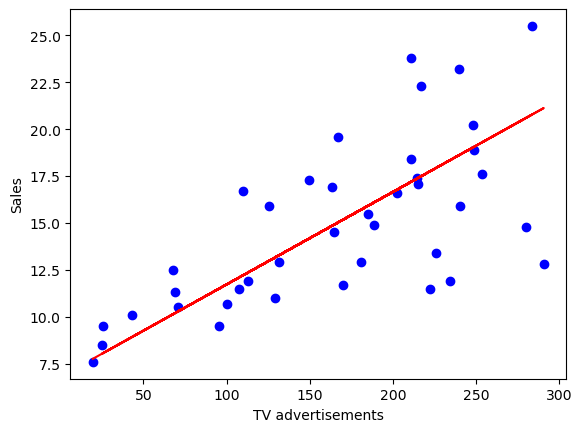

        TV
109   13.1
108   90.4
190   18.7
15   204.1
57     7.3
..     ...
134  219.8
138  273.7
73    26.8
141   73.4
38    74.7

[160 rows x 1 columns]
109     5.3
108     8.7
190     6.7
15     19.0
57      5.5
       ... 
134    19.6
138    20.8
73      8.8
141    10.9
38     14.7
Name: sales, Length: 160, dtype: float64


In [31]:
# Split the data for training and testing

from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(sales_data[['TV','radio','newspaper']],sales_data['sales'],test_size=0.2,random_state=1)

# Simple linear regression of TV

tv_data = x_train[['TV']]

model = LinearRegression()
model.fit(tv_data,y_train)

#Summaries 

print("Coefficient: " , model.coef_[0] )
print("Intercept: ", model.intercept_)
print(f"Equation: Sales={model.coef_[0]}*TV + {model.intercept_}")


#Predictions
predictions = model.predict(x_test[['TV']])

#Plotting the graph
plt.scatter(x_test['TV'], y_test, color ='b')
plt.plot(x_test['TV'], predictions, color ='r')
plt.xlabel('TV advertisements')
plt.ylabel("Sales")
plt.show()


print(tv_data)
print(y_train)



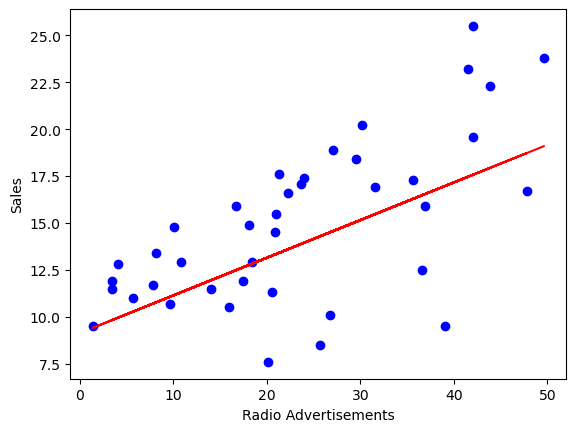

Cofficient:  0.2007188053072039
Intercept:  9.1341254885822
Equation: Sales= 0.2007188053072039*radio + 9.1341254885822


In [13]:

#Simple linear regression of Radio
radio_data = x_train[['radio']]
model.fit(radio_data,y_train)


#Predicting from the model
predictions = model.predict(x_test[['radio']])

#Plotting the graph
plt.scatter(x_test['radio'], y_test, color ='b')
plt.plot(x_test['radio'], predictions, color ='red')
plt.xlabel('Radio Advertisements')
plt.ylabel("Sales")
plt.show()



#Summaries 
print("Cofficient: ",model.coef_[0])
print("Intercept: ", model.intercept_)
print(f"Equation: Sales= {model.coef_[0]}*radio + {model.intercept_}")


Coefficient:  [0.07029362]
Intercept:  11.705780334816042
Equation: Sales = 0.07029362040510674*newspaper + 11.705780334816042


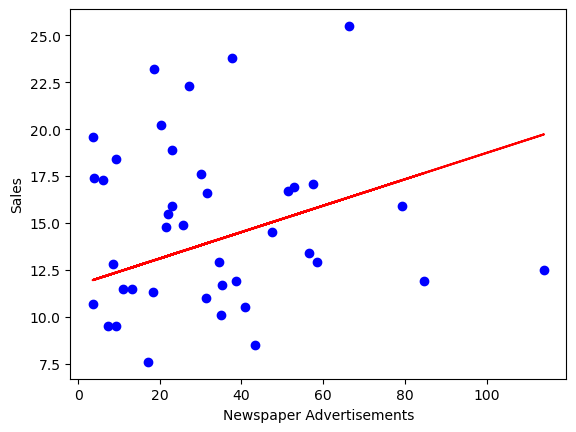

0.07029362040510674


In [14]:
#Simple linear regression of newspaper
newspaper_data = x_train[['newspaper']]
model.fit(newspaper_data,y_train)

#Summaries
print("Coefficient: ", model.coef_)
print("Intercept: ", model.intercept_)
print(f"Equation: Sales = {model.coef_[0]}*newspaper + {model.intercept_}")

#Predicting from datas
predictions = model.predict(x_test[['newspaper']])

#Plotting graph
plt.scatter(x_test['newspaper'], y_test, color ='b')
plt.plot(x_test['newspaper'], predictions, color ='r')
plt.xlabel('Newspaper Advertisements')
plt.ylabel("Sales")
plt.show()


print(model.coef_[0])


const    6.799773
TV       0.049275
dtype: float64


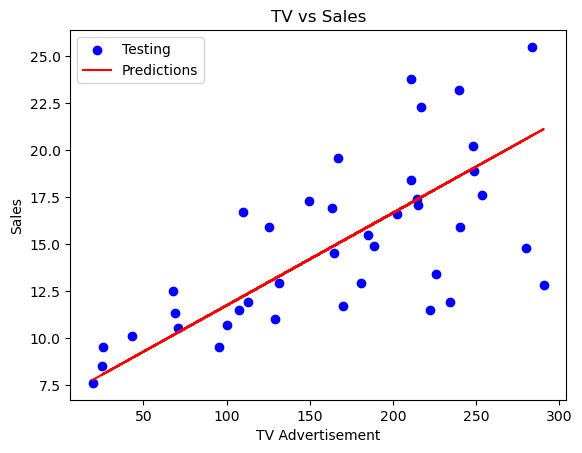

In [55]:
import pandas as pd

#Simple Linear Regression using statsmodels.api

x_train, x_test, y_train, y_test = train_test_split(sales_data[['TV','radio','newspaper']],sales_data['sales'],test_size=0.2,random_state=1)

# Simple linear regression of TV

X = x_train[['TV']]
X = sm.add_constant(tv_data)
Y= y_train


model = sm.OLS(Y,X)
result = model.fit()


print(result.params)

#Predicting from the model
x_test_sm = sm.add_constant(x_test[['TV']])
predictions = result.predict(x_test_sm)


#Plotting

plt.scatter(x_test['TV'],y_test,color='b',label='Testing')
plt.plot(x_test['TV'],predictions,color = 'r', label = 'Predictions')
plt.xlabel('TV Advertisement')
plt.ylabel('Sales')
plt.title("TV vs Sales")
plt.legend()
plt.show()


In [72]:
#Multiple Linear Regression using scikitlearn

x_train, x_test, y_train, y_test = train_test_split(sales_data[['TV','radio','newspaper']],sales_data['sales'],test_size=0.2,random_state=1)

model = LinearRegression()
model.fit(x_train,y_train)


print("========= Scikit Learn Simple Linear Regression ========")
print(f"\nCoefficients: {model.coef_}")
print(f"Intercept: {model.intercept_} \n\n")


#Multiple Linear Regression using statmodels.api

x_train_sm = x_train
x_train_sm = sm.add_constant(x_train_sm)
y_train_sm = y_train

model_stat = sm.OLS(y_train_sm,x_train_sm)

#fitting the model

result = model_stat.fit()

#Printing coefficients

print("========= Stat Models Ordinary Least Squares ========")
print(result.params)

#Printing summary

print(result.summary())







========= Scikit Learn Simple Linear Regression ========

Coefficients: [0.0468431  0.17854434 0.00258619]
Intercept: 2.9079470208164366 


========= Stat Models Ordinary Least Squares ========
const        2.907947
TV           0.046843
radio        0.178544
newspaper    0.002586
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     447.7
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.12e-76
Time:                        18:19:17   Log-Likelihood:                -315.37
No. Observations:                 160   AIC:                             638.7
Df Residuals:                     156   BIC:                             651.0
Df Model:                           3                                  

# Exercise 3
### a) Visualize any one of the simple linear regression models and the multiple linear regression model as plots

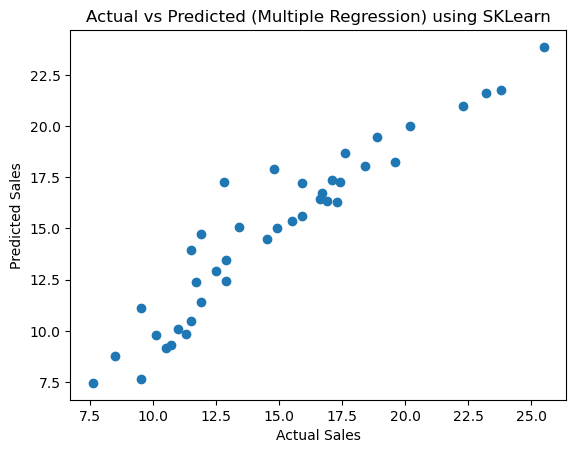

In [88]:
#Visualizing Multiple Linear Regression 

#Predicting from the model

prediction_sklearn = model.predict(x_test)

plt.scatter(y_test, prediction_sklearn)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Multiple Regression) using SKLearn")
plt.show()

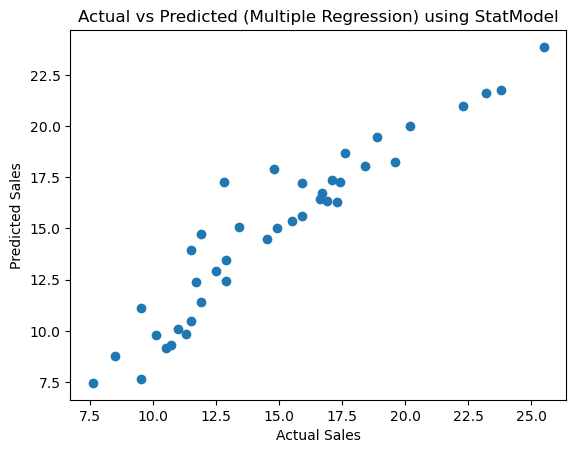

In [87]:
#Prediction using stats models

x_test_sm = sm.add_constant(x_test)
predictions_sm = result.predict(x_test_sm)

#Plotting graph 

plt.scatter(y_test, predictions_sm)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Multiple Regression) using StatModel")
plt.show()

# Exercise 4
### Fit the TV sales into a polynomial regression model with degree=4, print the summary and visualize the model as a plot

<class 'pandas.core.series.Series'>
19.6


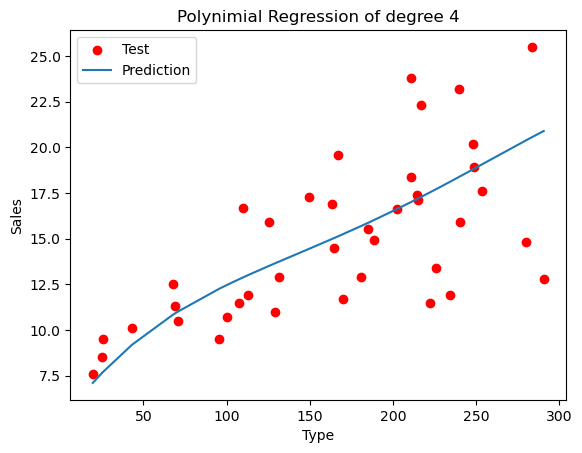

In [154]:
# Your code here

polynom = PolynomialFeatures(degree = 4)

tv_train_polynom = polynom.fit_transform(x_train[['TV']])
tv_test_polynom = polynom.transform(x_test[['TV']])


tv_train_polynom = sm.add_constant(tv_train_polynom)


model = sm.OLS(y_train,tv_train_polynom)
result = model.fit()

#print(result.summary())

#Make a predictions

tv_test_polynom = sm.add_constant(tv_test_polynom)
prediction = result.predict(tv_test_polynom)

#Plot
sorted_idx = np.argsort(x_test['TV'])
y_sorted = prediction[sorted_idx]
x_sorted = x_test['TV'].values[sorted_idx]

print(type(sorted_idx))

#print(y_sorted)
#print(x_sorted)
print(x_test['TV'][173])

plt.scatter(x_test['TV'],y_test,color='r',label = "Test")
plt.plot(x_sorted, y_sorted, label = "Prediction")
plt.xlabel('Type')
plt.ylabel('Sales')
plt.title("Polynimial Regression of degree 4")
plt.legend()
plt.show()

# Exercise 5
### Repeat Exercise 4 with degree=10 and note down your observations.

const    2.163749e-22
x1      -7.202506e-15
x2      -5.767106e-19
x3       2.132371e-16
x4       1.805293e-14
x5       1.227088e-12
x6       5.140210e-11
x7      -8.135268e-13
x8       4.847989e-15
x9      -1.284650e-17
x10      1.274563e-20
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                      -0.268
Model:                            OLS   Adj. R-squared:                 -0.301
Method:                 Least Squares   F-statistic:                    -8.189
Date:                Tue, 05 May 2026   Prob (F-statistic):               1.00
Time:                        20:47:07   Log-Likelihood:                -515.38
No. Observations:                 160   AIC:                             1041.
Df Residuals:                     155   BIC:                             1056.
Df Model:                           4                                         
Covariance Type:            nonr

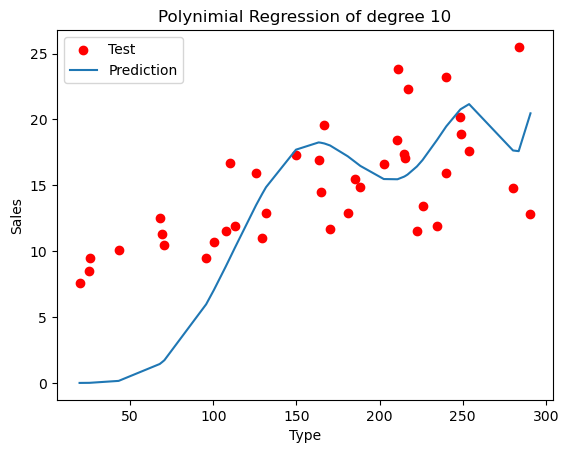

In [167]:
# Your code here

polynom = PolynomialFeatures(degree = 10)

tv_train_polynom = polynom.fit_transform(x_train[['TV']])
tv_test_polynom = polynom.fit_transform(x_test[['TV']])

tv_train_polynom = sm.add_constant(tv_train_polynom)


model = sm.OLS(y_train,tv_train_polynom)
result = model.fit()

print(result.params)

print(result.summary())

#Make a predictions

tv_test_polynom = sm.add_constant(tv_test_polynom)
prediction = result.predict(tv_test_polynom)

# Sort the data, otherwise the graph don't make any sense. 
sorted_idx = np.argsort(x_test['TV'])
y_sorted = prediction[sorted_idx]
x_sorted = x_test['TV'].values[sorted_idx]


#Plot
plt.scatter(x_test['TV'],y_test,color='r',label = "Test")
plt.plot(x_sorted, y_sorted, label = "Prediction")
plt.xlabel('Type')
plt.ylabel('Sales')
plt.title("Polynimial Regression of degree 10")
plt.legend()
plt.show()

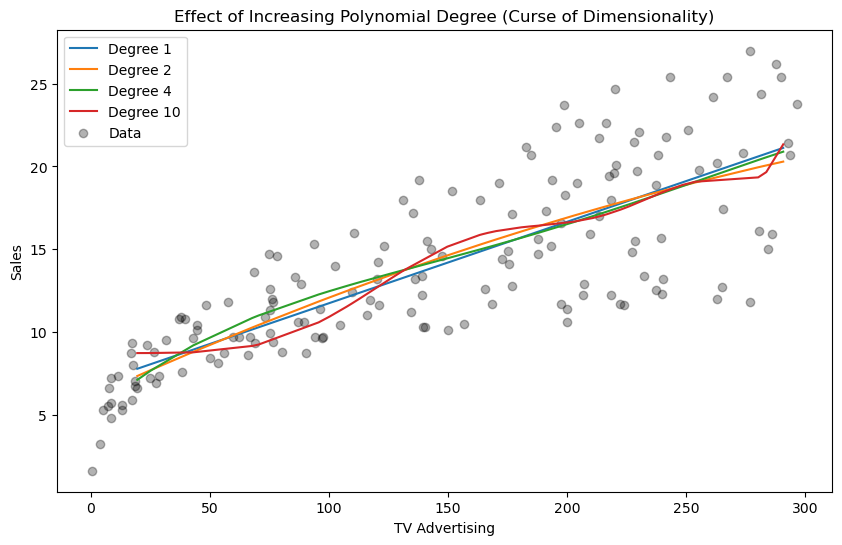

In [173]:
#Example of Curse of Dimension

#As degree increases, feature space explodes, model gets many dimensios.
# Model flexibility increases too much as it can pass through almosst every point.
# It stops learning the pattern andd start learning noise.
# Thats where the generaliztion gets much worse. Even if the training error improves, 
# test error increases and prediction become unstable.




import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression



x_train, x_test, y_train, y_test = train_test_split(sales_data[['TV','radio','newspaper']],sales_data['sales'],test_size=0.2,random_state=1)


plt.figure(figsize=(10,6))

for degree in [1, 2, 4, 10]:
    
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    X_train_poly = poly.fit_transform(x_train[['TV']])
    X_test_poly = poly.transform(x_test[['TV']])
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_pred = model.predict(X_test_poly)
    
    sorted_indx = np.argsort(x_test['TV'])
    x_sorted = x_test['TV'].values[sorted_indx]
    y_sorted = y_pred[sorted_indx]
    
   
    
    plt.plot(x_sorted, y_sorted, label=f"Degree {degree}")

# real data
plt.scatter(x_train['TV'], y_train, color='black', alpha=0.3, label="Data")

plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("Effect of Increasing Polynomial Degree (Curse of Dimensionality)")
plt.legend()
plt.show()